In [5]:
import kagglehub
import pandas as pd

# Load dataset
data_path = '/kaggle/input/wine-quality-red-and-white/wine_quality_merged.csv'
df = pd.read_csv(data_path, delimiter=',', encoding='ascii')

# Display basic info
print('Data shape:', df.shape)
df.head()

Data shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [8]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [11]:
from sklearn.model_selection import train_test_split
X = df.drop('quality', axis=1)
y = df['quality']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
categorical_features = ['type']
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[('cat',categorical_transformer,categorical_features)],
    remainder='passthrough'
)
pipeline = Pipeline(steps=[('preprocessor', preprocessor),('model', KNeighborsClassifier())])
model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Accuracy: {accuracy:.4f}')
print(f'F1 Score: {f1:.4f}')




 

Accuracy: 0.4569
F1 Score: 0.4435


In [28]:
# now applying the StandardScaler to the numeric features and retraining the model
from sklearn.model_selection import train_test_split
X = df.drop('quality', axis=1)
y = df['quality']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
categorical_features = ['type']
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
numeric_features =  ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
numeric_transformer = Pipeline(steps=[
                              ('scaler', StandardScaler())])
preprocessor = ColumnTransformer(
    transformers=[('cat',categorical_transformer,categorical_features),
                  ('numeric', numeric_transformer, numeric_features)],
    remainder='passthrough'
)
pipeline = Pipeline(steps=[('preprocessor', preprocessor),('model', KNeighborsClassifier(n_neighbors=20, weights='distance',metric='manhattan'))])
model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Accuracy: {accuracy:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 0.6708
F1 Score: 0.6586


In [27]:
# now applying the MinMaxScaler to the numeric features and retraining the model
from sklearn.model_selection import train_test_split
X = df.drop('quality', axis=1)
y = df['quality']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
categorical_features = ['type']
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
numeric_features =  ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
numeric_transformer = Pipeline(steps=[
                              ('scaler', MinMaxScaler())])
preprocessor = ColumnTransformer(
    transformers=[('cat',categorical_transformer,categorical_features),
                  ('numeric', numeric_transformer, numeric_features)],
    remainder='passthrough'
)
pipeline = Pipeline(steps=[('preprocessor', preprocessor),('model', KNeighborsClassifier(n_neighbors=20, weights='distance',metric='manhattan'))])
model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Accuracy: {accuracy:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 0.6677
F1 Score: 0.6574


In [17]:
# now applying the cross validation to find best K value for KNN model
from sklearn.model_selection import cross_val_score
for k in range(1, 21):
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),('model', KNeighborsClassifier(n_neighbors=k))])
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
    print(f'K: {k}, Cross-validated accuracy: {scores.mean():.4f}')

K: 1, Cross-validated accuracy: 0.4011
K: 2, Cross-validated accuracy: 0.4124
K: 3, Cross-validated accuracy: 0.4153
K: 4, Cross-validated accuracy: 0.4290
K: 5, Cross-validated accuracy: 0.4385
K: 6, Cross-validated accuracy: 0.4385
K: 7, Cross-validated accuracy: 0.4425
K: 8, Cross-validated accuracy: 0.4435
K: 9, Cross-validated accuracy: 0.4445
K: 10, Cross-validated accuracy: 0.4462
K: 11, Cross-validated accuracy: 0.4522
K: 12, Cross-validated accuracy: 0.4541
K: 13, Cross-validated accuracy: 0.4567
K: 14, Cross-validated accuracy: 0.4581
K: 15, Cross-validated accuracy: 0.4542
K: 16, Cross-validated accuracy: 0.4541
K: 17, Cross-validated accuracy: 0.4576
K: 18, Cross-validated accuracy: 0.4618
K: 19, Cross-validated accuracy: 0.4568
K: 20, Cross-validated accuracy: 0.4599


In [30]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'model__n_neighbors': list(range(1, 21)),
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan', 'minkowski']
}
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring=['accuracy', 'f1_weighted'], refit='accuracy')
grid_search.fit(X_train, y_train)
print(f'Best parameters: {grid_search.best_params_}')



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best parameters: {'model__metric': 'manhattan', 'model__n_neighbors': 20, 'model__weights': 'distance'}


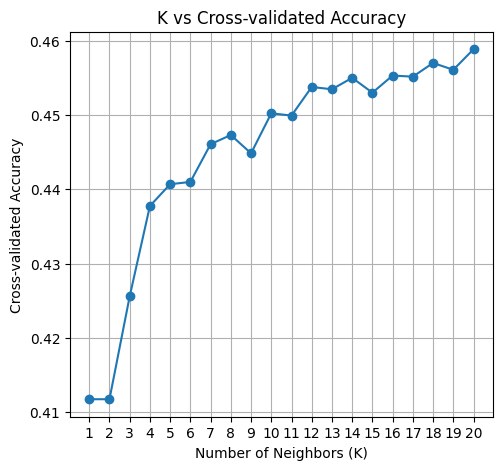

In [32]:
#plotting accuracy vs K
import matplotlib.pyplot as plt
k_values = list(range(1, 21))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values, [cross_val_score(Pipeline(steps=[('preprocessor', preprocessor),('model', KNeighborsClassifier(n_neighbors=k,weights='distance',metric='manhattan'))]), X, y, cv=5, scoring='accuracy').mean() for k in k_values], marker='o')
plt.title('K vs Cross-validated Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Cross-validated Accuracy')
plt.xticks(k_values)
plt.grid()
plt.show()

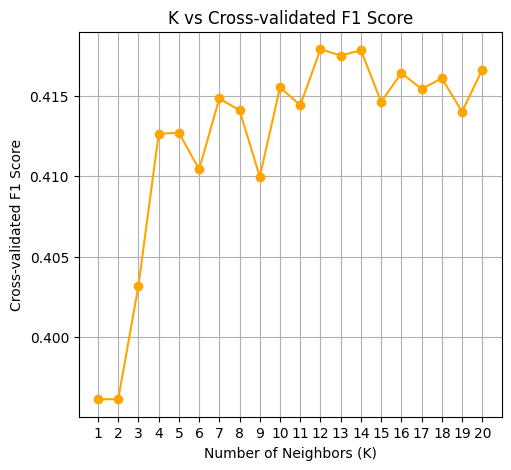

In [29]:
#plotting F1 score vs K
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
plt.plot(k_values, [cross_val_score(Pipeline(steps=[('preprocessor', preprocessor),('model', KNeighborsClassifier(n_neighbors=k,weights='distance',metric='manhattan'))]), X, y, cv=5, scoring='f1_weighted').mean() for k in k_values], marker='o', color='orange')
plt.title('K vs Cross-validated F1 Score')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Cross-validated F1 Score')
plt.xticks(k_values)
plt.grid()
plt.show()